In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,KFold
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score

In [6]:
df = pd.read_csv("/content/USA_Housing.csv")

In [7]:
df.sample(5)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
1624,85174.041761,4.977651,5.987958,4.01,38773.020820,1.363106e+06,USCGC Paul\nFPO AE 56892
1262,77334.286506,4.866819,8.509337,4.35,37905.983784,1.371670e+06,"270 Bonilla Mountains Suite 148\nBrennanfurt, ..."
1296,67026.440485,5.622597,5.560294,2.41,27677.882780,6.258807e+05,"3881 Brown Vista\nSharonburgh, DC 35897-2870"
4289,78705.909874,5.193469,7.609021,6.21,40204.520465,1.560270e+06,"763 Lisa Turnpike\nJosephstad, NE 53897-6198"
4301,82743.509306,6.514382,8.137475,5.30,41859.072400,1.811266e+06,"483 Ashley Heights\nLake Andrewshire, CT 40554"


In [29]:
df = df.drop(columns  = ['Address'])

In [30]:
df['Price'] = df['Price'].apply(lambda x: round(float(x),2))

In [32]:
numerical_features = ['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms','Avg. Area Number of Bedrooms','Area Population','Price']

In [33]:
df_num = df[numerical_features]

In [34]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

In [35]:
df_scaled = pd.DataFrame(df_scaled, columns=numerical_features)
df_scaled.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,1.028660,-0.296927,0.021274,0.088062,-1.317599,-0.490081
1,1.000808,0.025902,-0.255506,-0.722301,0.403999,0.775508
2,-0.684629,-0.112303,1.516243,0.930840,0.072410,-0.490211
3,-0.491499,1.221572,-1.393077,-0.584540,-0.186734,0.080843
4,-0.807073,-0.944834,0.846742,0.201513,-0.988387,-1.702518


In [37]:
df[numerical_features] = df_scaled


In [38]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,1.028660,-0.296927,0.021274,0.088062,-1.317599,-0.490081
1,1.000808,0.025902,-0.255506,-0.722301,0.403999,0.775508
2,-0.684629,-0.112303,1.516243,0.930840,0.072410,-0.490211
3,-0.491499,1.221572,-1.393077,-0.584540,-0.186734,0.080843
4,-0.807073,-0.944834,0.846742,0.201513,-0.988387,-1.702518


In [41]:
df.shape

(5000, 6)

In [42]:
df.isna().sum()

,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0


<Axes: xlabel='Price', ylabel='Count'>

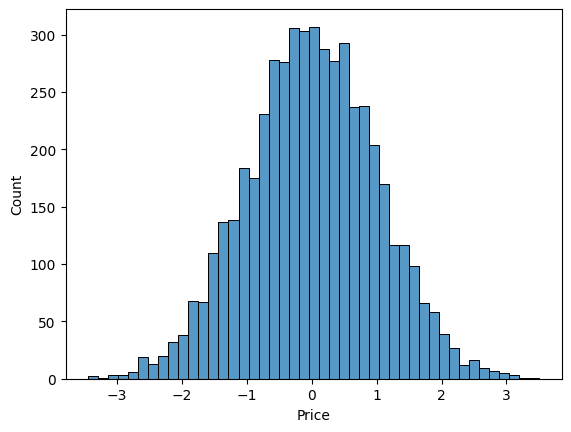

In [43]:
sns.histplot(df['Price'])

In [17]:
for i in df.columns:
  if df[i].isna().sum() > 0 :
    if df[i].dtypes() in [float,int]:
      df[i].fillna(df[i].median(),inplace = True)
    else:
      df[i].fillna(df[i].mode(),inplace = True)

In [46]:
X = df.drop(columns = ['Price'],axis = 1)
y = df['Price']

stratified by traintestsplit

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [48]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [49]:
y_pred = model.predict(X_test)

In [50]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
print("rmse",rmse,"r2",r2)

rmse 0.28447774629152417 r2 0.917997170446807


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
print("Model Evaluation Metrics:")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


Model Evaluation Metrics:
MAE  : 0.23
MSE  : 0.08
RMSE : 0.28
R²   : 0.9180


Actual vs Predicted Plot

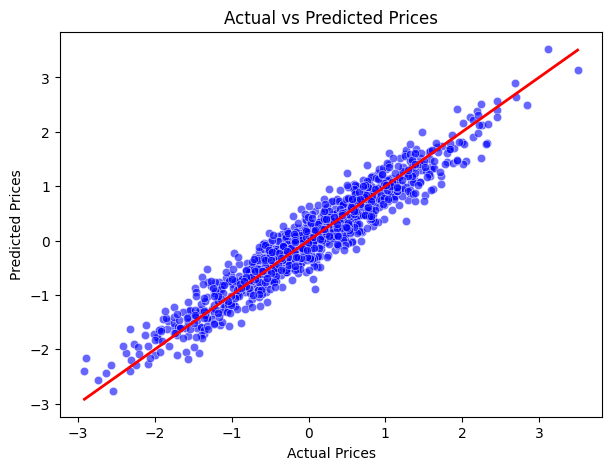

In [54]:


# Predicted vs Actual
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()


Residual Plot

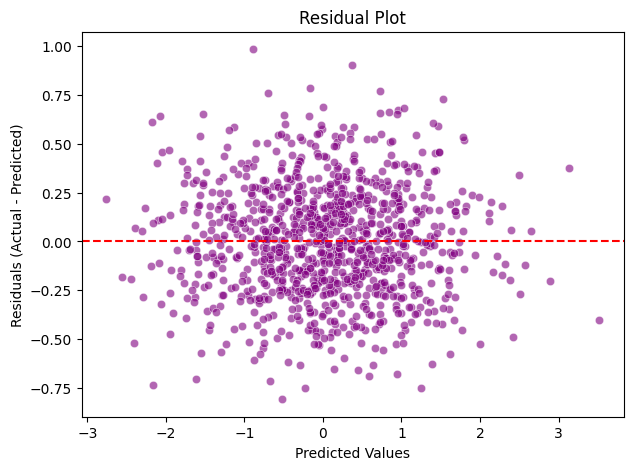

In [55]:
# Residuals
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred, y=residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()


Residual Distribution

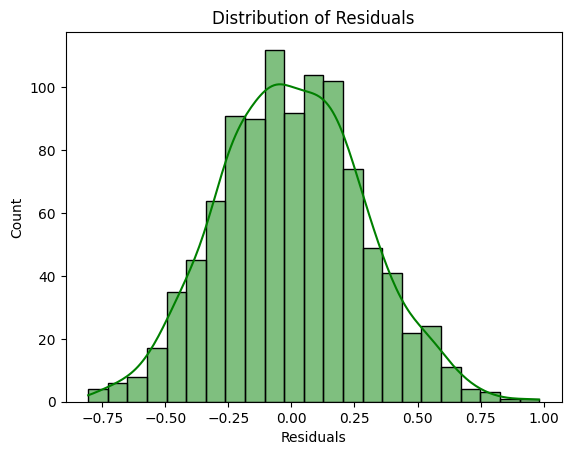

In [56]:
sns.histplot(residuals, kde=True, color='green')
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()
